# How Much Rainwater Does a Bank Filtration Well Extract?

## Learning Objectives
- Model a bank filtration system that mixes river water with local rainwater using `gwtransport.recharge`
- Represent strongly varying rainfall (dry spells, wet years, 20 mm cloudbursts in 4 hours) on a mixed-resolution time grid
- Quantify the rainwater fraction of the extracted water by source apportionment (superposition)
- Understand why the extracted mixture responds to rainfall on multi-year timescales, not to single storms

## Overview

A drinking-water well field extracts about 120 m³/day next to a river. Part of the extracted
water infiltrates from the river and travels through the aquifer to the well (bank filtration);
the rest is local rainwater that recharges the strip of land between the river and the well and
mixes into the groundwater on its way down-gradient. Operationally, the rainwater share matters:
it carries different solutes (here: hardly any chloride) and different risks than river water.

The aquifer is 15 m thick with a porosity of 0.30, so each square metre of strip stores
$n H = 4.5$ m³ of pore water. Rainfall averages 1.1 mm/day but varies heavily: dry summers, wet
winters, multi-year wet and dry periods, and occasional cloudbursts of 20 mm in 4 hours.

`gwtransport.recharge.recharge_to_extraction` solves this configuration exactly. Water with the
river concentration `cin` enters at the upstream side of the modelled pore volume whenever
extraction exceeds the rainfall on the strip; recharge with concentration `cin_recharge` enters
via the surface and mixes instantaneously over the depth. Transport is purely advective — there
is no dispersion or molecular diffusion — so the spread in the extracted signal is a residence-time
(mixing) effect, and the residence-time behaviour of the recharge follows Haitjema's exponential
model (Haitjema, 1995).

**A back-of-envelope number to set expectations.** For the well to consist of a fraction $f$ of
rainwater, the river water must spend about $T = \frac{nH}{N}\,\ln\frac{1}{1-f}$ travelling
through the strip (the time to accumulate $\ln\frac{1}{1-f}$ pore volumes of recharge). With
$nH = 4.5$ m and $N = 1.1$ mm/day, a 42 % rainwater share implies $T \approx 6.1$ years. The
extracted mixture therefore reflects *years* of accumulated rainfall, and the rainwater fraction
drifts on seasonal-to-decadal timescales no matter how spiky the rainfall input is. We simulate
30 years to capture that behaviour.

**Reference**: Haitjema, H.M. (1995). On the residence time distribution in idealized
groundwatersheds. *Journal of Hydrology*, 172(1-4), 127-146.
[doi:10.1016/0022-1694(95)02732-5](https://doi.org/10.1016/0022-1694(95)02732-5)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from gwtransport.recharge import recharge_to_extraction

rng = np.random.default_rng(7)

# Aquifer and well-field parameters
THICKNESS = 15.0  # aquifer thickness [m]
POROSITY = 0.30  # [-]
PORE_DEPTH = POROSITY * THICKNESS  # pore volume per unit area n*H [m]
FLOW_MEAN = 120.0  # mean extraction rate [m3/day]
RAIN_MEAN = 1.1e-3  # long-term mean recharge [m/day]

# Strip of land contributing recharge to the well, sized for a ~42 % mean rainwater share
TARGET_FRACTION = 0.42
AREA = TARGET_FRACTION * FLOW_MEAN / RAIN_MEAN  # [m2]
APV = AREA * PORE_DEPTH  # aquifer pore volume between river and well [m3]
print(f"strip area  : {AREA / 1e4:.1f} ha")
print(f"pore volume : {APV / 1e3:.0f} thousand m3")
print(
    f"travel time for a 42 % rain share: {PORE_DEPTH / RAIN_MEAN * np.log(1 / (1 - TARGET_FRACTION)) / 365:.1f} years"
)

strip area  : 4.6 ha
pore volume : 206 thousand m3
travel time for a 42 % rain share: 6.1 years


## Rainfall: 1.1 mm/day on average, anything but average in practice

Daily rainfall is generated as a wet/dry process modulated by a seasonal cycle (wet winters) and
two slow climate cycles (9-year and 3.7-year periods) that produce persistent wet and dry years.
On top of that, five days per year receive a 20 mm cloudburst that falls within 4 hours.

In [2]:
N_YEARS = 30
N_DAYS = N_YEARS * 365
day = np.arange(N_DAYS)

seasonal = 1.0 + 0.6 * np.cos(2 * np.pi * (day - 15) / 365)
interannual = (
    1.0 + 0.55 * np.sin(2 * np.pi * (day - 6.5 * 365) / (365 * 9)) + 0.30 * np.sin(2 * np.pi * day / (365 * 3.7) + 1.0)
)
interannual = np.maximum(interannual, 0.15)

wet_day = rng.random(N_DAYS) < 0.35
background_mm = np.where(wet_day, rng.exponential(1.0, N_DAYS), 0.0) * seasonal * interannual
storm_days = rng.choice(N_DAYS, size=N_YEARS * 5, replace=False)
storm_mm = np.zeros(N_DAYS)
storm_mm[storm_days] = 20.0  # 20 mm falling within 4 hours
background_mm *= (RAIN_MEAN * 1e3 * N_DAYS - storm_mm.sum()) / background_mm.sum()
rain_mm = background_mm + storm_mm
print(f"mean rainfall {rain_mm.mean():.2f} mm/day, wettest day {rain_mm.max():.0f} mm")

mean rainfall 1.10 mm/day, wettest day 36 mm


## A time grid that matches the question

The bin-edge pattern of gwtransport allows the resolution to vary along the record: the first
27 years use weekly bins (their influence on today's extracted water is heavily smoothed
anyway), and the last 3 years use 2-day bins. Cloudburst days in the recent era are split at
the 4-hour mark, so the storm enters the model at its true intensity of 120 mm/day rather than
diluted over a day. The extraction rate varies seasonally (higher summer demand) and includes
two multi-year episodes: reduced pumping during the wet years 9-13 and increased pumping during
the dry years 19-23.

The bins of the input series are also the spin-up assumption: `recharge_to_extraction` treats
all inputs as constant at their first values before the record starts. The first bin is
therefore set to long-term average conditions, so the simulation starts from the steady mixture
rather than from an arbitrarily wet or dry first week.

In [3]:
SPLIT_DAY = (N_YEARS - 3) * 365
recent_storms = set(storm_days[storm_days >= SPLIT_DAY])

edges = [0.0]
d = 0
while d < SPLIT_DAY:  # weekly history
    edges.append(min(d + 7, SPLIT_DAY))
    d += 7
d = SPLIT_DAY
while d < N_DAYS:  # 2-day recent era, cloudburst days split at +4 h
    step = min(2, N_DAYS - d)
    for dd in range(d, d + step):
        if dd in recent_storms:
            edges.extend([dd + 4 / 24, dd + 1.0])
    edges.append(float(d + step))
    d += step
edges = np.unique(np.array(edges, dtype=float))

# Exact bin-average recharge rates from the daily series (storm volume in the first 4 h of its day)
cum_mm = np.concatenate([[0.0], np.cumsum(rain_mm)])
day_idx = np.clip(np.floor(edges).astype(int), 0, N_DAYS - 1)
frac_of_day = edges - np.floor(edges)
cum_at_edges = (
    cum_mm[day_idx] + np.minimum(frac_of_day / (4 / 24), 1.0) * storm_mm[day_idx] + frac_of_day * background_mm[day_idx]
)
cum_at_edges[-1] = cum_mm[-1]
recharge = np.diff(cum_at_edges) / np.diff(edges) / 1000.0  # [m/day] per bin

mid = 0.5 * (edges[:-1] + edges[1:])
flow = FLOW_MEAN * (1.0 + 0.35 * np.cos(2 * np.pi * (mid - 200) / 365))
flow *= np.where((mid > 9 * 365) & (mid < 13 * 365), 0.62, 1.0)  # wet years, reduced demand
flow *= np.where((mid > 19 * 365) & (mid < 23 * 365), 1.55, 1.0)  # dry years, drought demand

recharge[0], flow[0] = RAIN_MEAN, FLOW_MEAN  # representative first bin -> steady-mixture spin-up

tedges = pd.DatetimeIndex(pd.Timestamp("1995-01-01") + pd.to_timedelta(edges, unit="D"))
print(f"{len(recharge)} input bins, {np.sum(np.diff(edges) < 1)} of them 4-hour storm bins")

1968 input bins, 12 of them 4-hour storm bins


## Concentrations: chloride as the mixing tracer

River chloride varies seasonally between roughly 60 and 95 mg/L (low flows concentrate the
river in late summer); rainwater carries about 4 mg/L. Chloride behaves conservatively, so
`retardation_factor` keeps its default of 1.

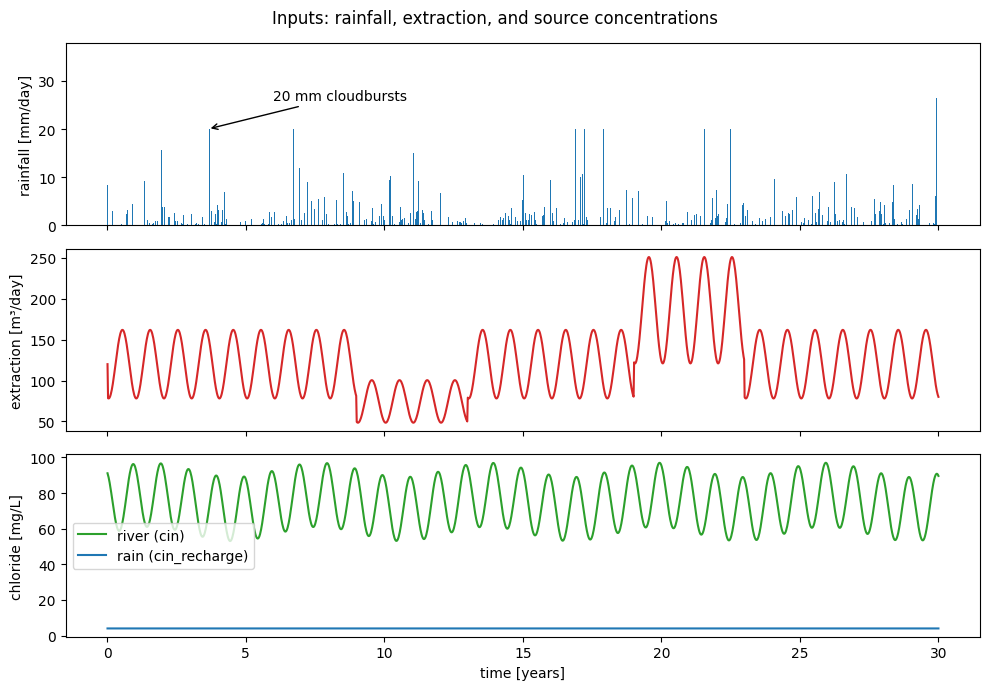

In [4]:
cin_river = 75.0 + 18.0 * np.sin(2 * np.pi * (mid - 250) / 365) + 4.0 * np.sin(2 * np.pi * mid / (365 * 6.1))
cin_rain = np.full_like(mid, 4.0)

fig, axs = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
t_yr = mid / 365
axs[0].bar(day / 365, rain_mm, width=1 / 365, color="tab:blue")
axs[0].set_ylabel("rainfall [mm/day]")
axs[0].annotate("20 mm cloudbursts", xy=(storm_days[5] / 365, 20), xytext=(6, 26), arrowprops={"arrowstyle": "->"})
axs[1].plot(t_yr, flow, color="tab:red")
axs[1].set_ylabel("extraction [m³/day]")
axs[2].plot(t_yr, cin_river, color="tab:green", label="river (cin)")
axs[2].plot(t_yr, cin_rain, color="tab:blue", label="rain (cin_recharge)")
axs[2].set_ylabel("chloride [mg/L]")
axs[2].set_xlabel("time [years]")
axs[2].legend()
fig.suptitle("Inputs: rainfall, extraction, and source concentrations")
fig.tight_layout()

## Extracted concentration

One call computes the chloride concentration of the extracted water, exactly: the upstream
boundary supplies river water whenever extraction exceeds the rainfall on the strip, and during
rainfall surpluses (every cloudburst, and parts of the wet years) the flow at the upstream side
briefly reverses and pushes groundwater back out, where it is lost.

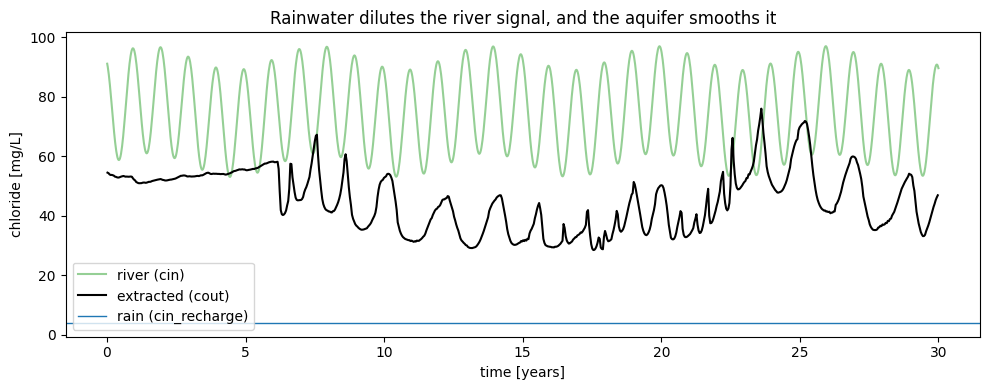

In [5]:
cout_edges_days = np.arange(0.0, N_DAYS + 1, 14.0)
cout_tedges = pd.DatetimeIndex(pd.Timestamp("1995-01-01") + pd.to_timedelta(cout_edges_days, unit="D"))

cout = recharge_to_extraction(
    cin=cin_river,
    cin_recharge=cin_rain,
    flow=flow,
    recharge=recharge,
    tedges=tedges,
    cout_tedges=cout_tedges,
    aquifer_pore_volume=APV,
    aquifer_pore_depth=PORE_DEPTH,
)

t_out = 0.5 * (cout_edges_days[:-1] + cout_edges_days[1:]) / 365
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_yr, cin_river, color="tab:green", alpha=0.5, label="river (cin)")
ax.plot(t_out, cout, color="black", label="extracted (cout)")
ax.axhline(4.0, color="tab:blue", lw=1, label="rain (cin_recharge)")
ax.set_xlabel("time [years]")
ax.set_ylabel("chloride [mg/L]")
ax.legend()
ax.set_title("Rainwater dilutes the river signal, and the aquifer smooths it")
fig.tight_layout()

The extracted water sits well below the river concentration (rainwater dilution) and the
seasonal river swings arrive damped and delayed: the well blends river water that infiltrated
over a window of several years.

## Source apportionment: how much rainwater?

Because the model is linear in the two source concentrations, running it once with
`cin = 1, cin_recharge = 0` and once with the ones swapped yields the volumetric fraction of
each source in every output bin. The two fractions sum to exactly one.

fractions sum to one within 3.3e-16
rainwater fraction: 0.20 to 0.58, mean 0.41


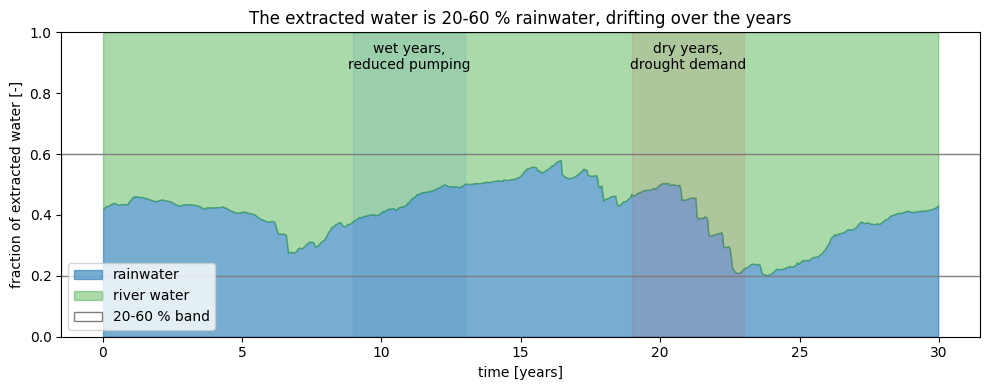

In [6]:
n = len(recharge)
frac_river = recharge_to_extraction(
    cin=np.ones(n),
    cin_recharge=np.zeros(n),
    flow=flow,
    recharge=recharge,
    tedges=tedges,
    cout_tedges=cout_tedges,
    aquifer_pore_volume=APV,
    aquifer_pore_depth=PORE_DEPTH,
)
frac_rain = recharge_to_extraction(
    cin=np.zeros(n),
    cin_recharge=np.ones(n),
    flow=flow,
    recharge=recharge,
    tedges=tedges,
    cout_tedges=cout_tedges,
    aquifer_pore_volume=APV,
    aquifer_pore_depth=PORE_DEPTH,
)
print(f"fractions sum to one within {np.nanmax(np.abs(frac_river + frac_rain - 1)):.1e}")
print(f"rainwater fraction: {np.nanmin(frac_rain):.2f} to {np.nanmax(frac_rain):.2f}, mean {np.nanmean(frac_rain):.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(t_out, 0, frac_rain, color="tab:blue", alpha=0.6, label="rainwater")
ax.fill_between(t_out, frac_rain, 1, color="tab:green", alpha=0.4, label="river water")
ax.axhspan(0.2, 0.6, facecolor="none", edgecolor="gray", label="20-60 % band")
ax.axvspan(9, 13, color="tab:blue", alpha=0.10)
ax.axvspan(19, 23, color="tab:red", alpha=0.10)
ax.annotate("wet years,\nreduced pumping", xy=(11, 0.88), ha="center")
ax.annotate("dry years,\ndrought demand", xy=(21, 0.88), ha="center")
ax.set_xlabel("time [years]")
ax.set_ylabel("fraction of extracted water [-]")
ax.set_ylim(0, 1)
ax.legend(loc="lower left")
ax.set_title("The extracted water is 20-60 % rainwater, drifting over the years")
fig.tight_layout()

The rainwater share drifts between roughly 20 % and 60 %. It rises with a delay of years after
wet periods (and when pumping is reduced: the same rainfall then makes up a larger share of a
smaller extraction) and falls during the drought years, when extra demand pulls in more river
water. The 4-hour cloudbursts, dramatic in the input, are invisible here as events - they only
matter through their contribution to the multi-year rainfall budget.

## Zoom: a 20 mm cloudburst at the well

During the burst, rainfall on the strip (120 mm/day over 4.6 ha, about 5500 m³/day) overwhelms
the extraction roughly fifty-fold; the upstream inflow reverses and the surplus is lost to the
river side.
At the well, however, the event leaves no visible trace: the aquifer is a low-pass filter with a
multi-year memory.

storm step after one month: -0.136 mg/L


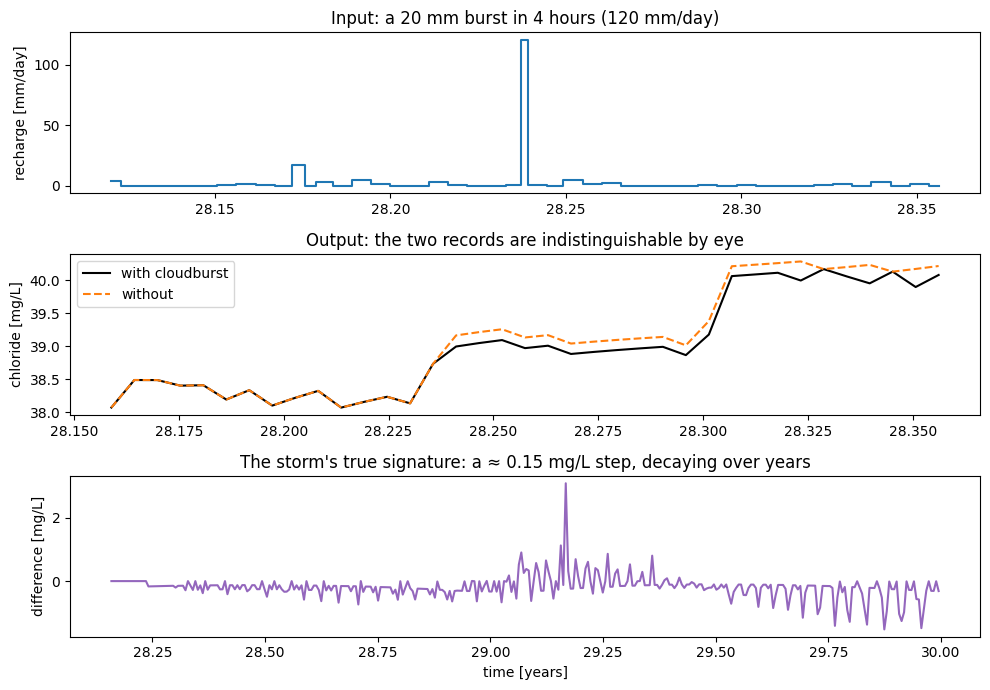

In [7]:
zoom_storm = sorted(recent_storms)[1]

# the same record without this one cloudburst
storm_mm_alt = storm_mm.copy()
storm_mm_alt[zoom_storm] = 0.0
cum_alt = np.concatenate([[0.0], np.cumsum(background_mm + storm_mm_alt)])
cum_alt_edges = (
    cum_alt[day_idx]
    + np.minimum(frac_of_day / (4 / 24), 1.0) * storm_mm_alt[day_idx]
    + frac_of_day * background_mm[day_idx]
)
cum_alt_edges[-1] = cum_alt[-1]
recharge_alt = np.diff(cum_alt_edges) / np.diff(edges) / 1000.0
recharge_alt[0] = RAIN_MEAN

fine_edges = np.arange(zoom_storm - 30.0, N_DAYS + 1, 2.0)
fine_tedges = pd.DatetimeIndex(pd.Timestamp("1995-01-01") + pd.to_timedelta(fine_edges, unit="D"))
cout_with = recharge_to_extraction(
    cin=cin_river,
    cin_recharge=cin_rain,
    flow=flow,
    recharge=recharge,
    tedges=tedges,
    cout_tedges=fine_tedges,
    aquifer_pore_volume=APV,
    aquifer_pore_depth=PORE_DEPTH,
)
cout_without = recharge_to_extraction(
    cin=cin_river,
    cin_recharge=cin_rain,
    flow=flow,
    recharge=recharge_alt,
    tedges=tedges,
    cout_tedges=fine_tedges,
    aquifer_pore_volume=APV,
    aquifer_pore_depth=PORE_DEPTH,
)

fig, axs = plt.subplots(3, 1, figsize=(10, 7))
in_window = np.abs(mid - zoom_storm) < 45
axs[0].step(mid[in_window] / 365, 1e3 * recharge[in_window], where="mid", color="tab:blue")
axs[0].set_ylabel("recharge [mm/day]")
axs[0].set_title("Input: a 20 mm burst in 4 hours (120 mm/day)")
t_fine = 0.5 * (fine_edges[:-1] + fine_edges[1:]) / 365
near = np.abs(t_fine * 365 - zoom_storm) < 45
axs[1].plot(t_fine[near], cout_with[near], color="black", label="with cloudburst")
axs[1].plot(t_fine[near], cout_without[near], color="tab:orange", ls="--", label="without")
axs[1].set_ylabel("chloride [mg/L]")
axs[1].legend()
axs[1].set_title("Output: the two records are indistinguishable by eye")
axs[2].plot(t_fine, cout_with - cout_without, color="tab:purple")
axs[2].set_ylabel("difference [mg/L]")
axs[2].set_xlabel("time [years]")
axs[2].set_title("The storm's true signature: a \u2248 0.15 mg/L step, decaying over years")
fig.tight_layout()
print(f"storm step after one month: {(cout_with - cout_without)[near][-1]:.3f} mg/L")

## Takeaways

- `recharge_to_extraction` mixes two sources exactly: river water entering at the upstream side
  (`cin`) and rainwater recharging the strip (`cin_recharge`). Two extra runs with unit
  concentrations turn the same model into a source-apportionment tool.
- With $nH = 4.5$ m of pore storage and 1.1 mm/day of rainfall, a 20-60 % rainwater share
  implies river-to-well travel times of about 2 to 10 years. The mixture composition is a
  multi-year running blend of the rainfall history and the pumping regime.
- Single storms - even 20 mm in 4 hours - briefly reverse the upstream boundary (the surplus
  water is lost toward the river), yet at the well they amount to a persistent step of only
  ≈ 0.15 mg/L (the burst is 0.4 % of a pore volume), invisible next to the seasonal swings. Wet *years* and
  pumping decisions, not wet *days*, set the rainwater share.
- The mixed-resolution time grid (weekly history, 2-day recent era, 4-hour storm bins) keeps
  the input honest where it matters without inflating the computation: the full 30-year run
  takes well under a second.